# Khám phá dữ liệu và thử một quy tắc đơn giản

Mỗi mẫu gồm hai ảnh chân dung `image_0` và `image_1`, có đúng một ảnh giả. Nhãn `fake_position = 0` nghĩa là ảnh trái giả; nhãn 1 nghĩa là ảnh phải giả.

Trong bài thi, một mốc dự đoán đơn giản giúp ta biết mình đang bắt đầu ở đâu. Ta sẽ xem ảnh, tìm một dấu hiệu đo được, chốt quy tắc từ phần train rồi kiểm tra quy tắc trên validation. Các ca đoán sai sẽ gợi ý những câu hỏi tiếp theo về màu sắc, chi tiết và vị trí trong ảnh.

Bài này dùng 800 cặp development đã chia sẵn. Khảo sát phân bố trên phần train của fold 0, gồm fold 1 và 2; dùng fold 0 để kiểm tra quy tắc. Sau này, điểm OOF trên cả 800 cặp vẫn là điểm phát triển phương pháp, vì dữ liệu này đã tham gia vào quá trình chọn đặc trưng. 200 cặp còn lại và private chưa được dùng ở đây.

Code có thể chạy độc lập với các notebook khác sau khi cài môi trường theo README và đặt `DATA_ROOT`. Các hình và bảng bên dưới sẽ được tạo từ dữ liệu khi chạy; phần chữ hướng dẫn cách đọc chúng.

In [1]:
from pathlib import Path
import os
import sys

def find_task_root():
    explicit = os.environ.get('KMD_PROJECT_ROOT')
    if explicit:
        root = Path(explicit).expanduser().resolve()
        if (root / 'src/kmd').is_dir():
            return root
        raise FileNotFoundError('KMD_PROJECT_ROOT phải trỏ đến thư mục KeMaoDanh chứa src/kmd.')
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / 'src/kmd').is_dir() and (cand / 'configs').is_dir():
            return cand.resolve()
        if (cand / 'KeMaoDanh/src/kmd').is_dir() and (cand / 'KeMaoDanh/configs').is_dir():
            return (cand / 'KeMaoDanh').resolve()
    raise FileNotFoundError("Không tìm thấy thư mục gốc KeMaoDanh chứa 'src/kmd' và 'configs'.")

TASK_ROOT = find_task_root()
if str(TASK_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(TASK_ROOT / 'src'))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from kmd.core import PACKAGE, read_csv, split_fold, metric
from kmd.pipeline import prepare_development
from kmd.teaching import resolve_data_roots, show_pair_images

KMD_SMOKE = os.environ.get('KMD_SMOKE', '0') == '1'
KMD_RUN_ID = os.environ.get('KMD_RUN_ID', 'reasoning_pilot')
RUN_ID = f"{KMD_RUN_ID}_smoke" if (KMD_SMOKE and not KMD_RUN_ID.endswith('_smoke')) else KMD_RUN_ID

data_root, test_root = resolve_data_roots(TASK_ROOT)
if not data_root.is_dir() or not (data_root / 'pairs.csv').is_file():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục dữ liệu huấn luyện tại '{data_root}'. "
        "Vui lòng thiết lập biến môi trường DATA_ROOT trỏ đến thư mục chứa 'pairs.csv' và 'images/'."
    )

dev_frame = prepare_development(data_root)
print(f"Thư mục dự án: {TASK_ROOT}")
print(f"Phiên làm việc: {RUN_ID}")
print(f"Tổng số cặp trong tập phát triển: {len(dev_frame)}")

Thư mục dự án: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh
Phiên làm việc: lesson_full_v5_20260920
Tổng số cặp trong tập phát triển: 800


## 1. Kiểm tra trước khi tìm tín hiệu

Ta cần biết ảnh có cùng kích thước và định dạng không: nếu một nhóm có ảnh lớn hơn nhóm kia, dung lượng tệp có thể khác chỉ vì số điểm ảnh. Tệp hỏng hoặc thiếu cũng cần được phát hiện trước khi đo.

`prepare_development` ghép dữ liệu với danh sách chia tập cố định; `split_fold` lấy hai fold làm train và một fold làm validation. Số cặp thực tế được in dưới đây. Hai ảnh của một cặp luôn đi cùng nhau.

In [2]:
tr_fold0, va_fold0 = split_fold(dev_frame, fold=0)
print(f"Số cặp trong tập huấn luyện Fold 0: {len(tr_fold0)}")
print(f"Số cặp trong tập kiểm định Fold 0:   {len(va_fold0)}")

image_shapes = set()
channels = set()
formats = set()
missing_count = 0

for row in tr_fold0.itertuples():
    for img_name in (row.image_0, row.image_1):
        img_file = data_root / img_name
        if not img_file.is_file():
            missing_count += 1
            continue
        formats.add(img_file.suffix.lower())
        img = cv2.imread(str(img_file), cv2.IMREAD_UNCHANGED)
        if img is None:
            missing_count += 1
        else:
            image_shapes.add((img.shape[0], img.shape[1]))
            channels.add(1 if img.ndim == 2 else img.shape[2])

print(f"Kích thước điểm ảnh (cao, rộng): {image_shapes}")
print(f"Số kênh màu: {channels}")
print(f"Số tệp không đọc được: {missing_count}")
print(f"Đuôi tệp: {sorted(formats)}")
if missing_count:
    raise ValueError("Có ảnh thiếu hoặc không đọc được; cần kiểm tra dữ liệu trước khi tiếp tục.")

Số cặp trong tập huấn luyện Fold 0: 533
Số cặp trong tập kiểm định Fold 0:   267


Kích thước điểm ảnh (cao, rộng): {(512, 512)}
Số kênh màu: {3}
Số tệp không đọc được: 0
Đuôi tệp: ['.jpg']


## 2. Nhìn một cặp trước khi đo

Lấy cặp có `pair_id` nhỏ nhất trong phần train để lần chạy sau vẫn xem đúng ví dụ này. Hãy nhìn cả khuôn mặt lẫn phần nền, rồi so với nhãn. Bạn có chỉ ra được chi tiết khiến mình chọn một bên không?

Một cặp chỉ giúp đặt câu hỏi. Để biết dấu hiệu có lặp lại hay không, ta cần đo trên nhiều ảnh. Dung lượng tệp là điểm bắt đầu thuận tiện vì lấy được ngay, không cần huấn luyện.

Cặp mẫu: pair_id=00001, fake_position=1
Ảnh 0: images/00295.jpg, dung lượng: 63,800 bytes
Ảnh 1: images/01131.jpg, dung lượng: 90,053 bytes


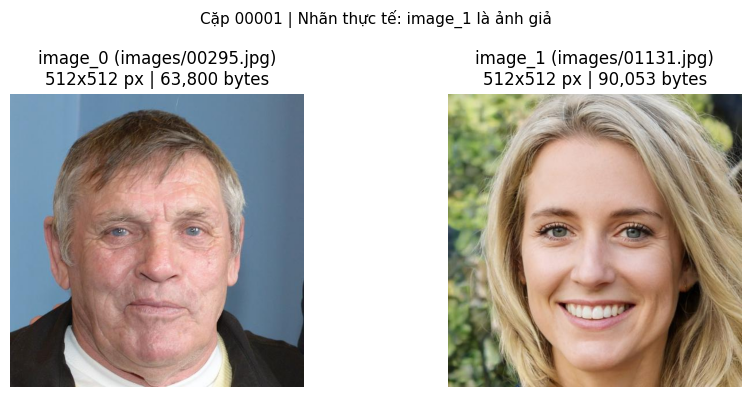

In [3]:
sample_row = tr_fold0.sort_values('pair_id').iloc[0]
p0 = data_root / sample_row.image_0
p1 = data_root / sample_row.image_1

print(f"Cặp mẫu: pair_id={sample_row.pair_id}, fake_position={sample_row.fake_position}")
print(f"Ảnh 0: {sample_row.image_0}, dung lượng: {p0.stat().st_size:,} bytes")
print(f"Ảnh 1: {sample_row.image_1}, dung lượng: {p1.stat().st_size:,} bytes")
show_pair_images(sample_row, data_root)

## 3. Dung lượng tệp có liên quan đến nhãn không?

Dung lượng JPEG chịu ảnh hưởng của nội dung ảnh và cách nén. Hai nhóm ảnh có thể khác về một trong hai yếu tố này. Vì vậy, ta thử kiểm tra dung lượng trước; nếu có khác biệt, vẫn cần tìm hiểu nó đến từ đâu.

Đo số byte rồi dùng `ln(1 + bytes)` để thu hẹp khoảng cách giữa các giá trị lớn khi vẽ. Log là phép biến đổi tăng: tệp nhẹ hơn vẫn có giá trị nhỏ hơn. Số 1 giúp công thức xác định cả ở giá trị 0; ảnh hợp lệ ở đây có dung lượng dương.

Ta dùng nhãn cặp để gom ảnh thật và giả trong phần train, sau đó so phân bố và trung vị. Trung vị là giá trị ở giữa khi sắp các số đo; nó giúp mô tả vị trí điển hình của mỗi nhóm.

In [4]:
real_log_bytes = []
fake_log_bytes = []

for row in tr_fold0.itertuples():
    p0_file = data_root / row.image_0
    p1_file = data_root / row.image_1
    b0 = float(np.log1p(p0_file.stat().st_size))
    b1 = float(np.log1p(p1_file.stat().st_size))
    
    if row.fake_position == 0:
        fake_log_bytes.append(b0)
        real_log_bytes.append(b1)
    else:
        real_log_bytes.append(b0)
        fake_log_bytes.append(b1)

med_real_bytes = float(np.median(real_log_bytes))
med_fake_bytes = float(np.median(fake_log_bytes))

print(f"Giá trị ln(1 + bytes) cặp mẫu: image_0={np.log1p(p0.stat().st_size):.4f}, image_1={np.log1p(p1.stat().st_size):.4f}")
print(f"Trung vị ln(1 + bytes) của ảnh thật trên train Fold 0: {med_real_bytes:.4f}")
print(f"Trung vị ln(1 + bytes) của ảnh giả trên train Fold 0:  {med_fake_bytes:.4f}")

Giá trị ln(1 + bytes) cặp mẫu: image_0=11.0635, image_1=11.4082
Trung vị ln(1 + bytes) của ảnh thật trên train Fold 0: 11.2336
Trung vị ln(1 + bytes) của ảnh giả trên train Fold 0:  11.0893


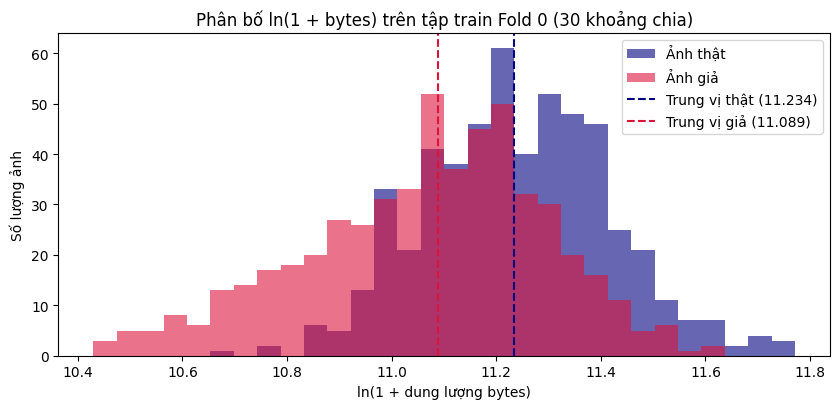

In [5]:
def histogram_edges(a, b, bins=30):
    low, high = min(a + b), max(a + b)
    if low == high:
        padding = max(abs(low) * 0.01, 0.001)
        low, high = low - padding, high + padding
    return np.linspace(low, high, bins + 1)

bins_bytes = histogram_edges(real_log_bytes, fake_log_bytes)

plt.figure(figsize=(8.5, 4.2))
plt.hist(real_log_bytes, bins=bins_bytes, alpha=0.6, color='navy', label='Ảnh thật')
plt.hist(fake_log_bytes, bins=bins_bytes, alpha=0.6, color='crimson', label='Ảnh giả')
plt.axvline(med_real_bytes, color='navy', linestyle='--', label=f'Trung vị thật ({med_real_bytes:.3f})')
plt.axvline(med_fake_bytes, color='crimson', linestyle='--', label=f'Trung vị giả ({med_fake_bytes:.3f})')
plt.title("Phân bố ln(1 + bytes) trên tập train Fold 0 (30 khoảng chia)")
plt.xlabel("ln(1 + dung lượng bytes)")
plt.ylabel("Số lượng ảnh")
plt.legend()
plt.tight_layout()
plt.show()

### Đọc phân bố rồi chọn quy tắc để thử

Trục ngang là log dung lượng; chiều cao cột là số ảnh trong khoảng đó. Hai nhóm dùng cùng 30 khoảng chia để so được với nhau. Đây là lựa chọn hiển thị, không phải một tham số đã tối ưu.

Hãy đọc hai việc riêng: trung vị nhóm nào thấp hơn, và hai nhóm chồng lấn ở đâu. Trung vị khác nhau gợi ý một hướng dự đoán; phần chồng lấn cho thấy không thể chỉ nhìn một giá trị dung lượng rồi chắc chắn biết nhãn.

Ta thử chọn ảnh nhẹ hơn nếu trung vị ảnh giả thấp hơn, chọn ảnh nặng hơn nếu trung vị ảnh giả cao hơn. Nếu hai trung vị bằng nhau, phép đo chưa chỉ ra hướng nào: quy tắc dự phòng đoán vị trí 0. Hai tệp trong một cặp bằng dung lượng cũng được xử lý bằng cách đoán 0. Đây là quy tắc đơn giản để kiểm tra, chưa phải ngưỡng phân loại tối ưu.

## 4. Giữ nguyên quy tắc rồi chấm trên validation

Sau khi chốt hướng từ train, ta áp dụng nguyên quy tắc cho fold 0. Không đổi chiều dự đoán sau khi nhìn điểm validation.

Bảng in Macro-F1 theo metric bài thi, accuracy và số cặp sai. Quy tắc chỉ trả nhãn cứng; các số 0/1 truyền vào hàm chấm không phải xác suất đã được hiệu chuẩn.

In [6]:
median_tie = med_fake_bytes == med_real_bytes
predict_lighter = med_fake_bytes < med_real_bytes
rule_label = "dự đoán ảnh nhẹ hơn là ảnh giả" if predict_lighter else "dự đoán ảnh nặng hơn là ảnh giả"
if median_tie:
    rule_label = "hai trung vị bằng nhau, dùng vị trí 0"
print(f"Quy tắc đã chốt từ train: {rule_label}")

val_records = []
for row in va_fold0.sort_values('pair_id').itertuples():
    b0 = float(np.log1p((data_root / row.image_0).stat().st_size))
    b1 = float(np.log1p((data_root / row.image_1).stat().st_size))
    delta_b = b1 - b0
    
    pred = 0 if median_tie else int(delta_b < 0 if predict_lighter else delta_b > 0)
    val_records.append({
        'pair_id': row.pair_id,
        'image_0': row.image_0,
        'image_1': row.image_1,
        'fake_position': int(row.fake_position),
        'delta_b': delta_b,
        'pred': pred,
        'is_correct': int(pred == row.fake_position)
    })

val_df = pd.DataFrame(val_records)
rule_metrics = metric(val_df['fake_position'], val_df['pred'])
print(f"Kết quả quy tắc dung lượng trên Validation Fold 0 ({rule_metrics['n']} cặp):")
print(f"- Macro-F1: {rule_metrics['macro_f1'] * 100:.2f}%")
print(f"- Accuracy: {rule_metrics['accuracy'] * 100:.2f}%")
print(f"- Số lỗi:   {rule_metrics['errors']} cặp")

cm = confusion_matrix(val_df['fake_position'], val_df['pred'], labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=['Thực tế: vị trí 0', 'Thực tế: vị trí 1'],
    columns=['Dự đoán: vị trí 0', 'Dự đoán: vị trí 1']
)
print("\nMa trận nhầm lẫn:")
print(cm_df)

Quy tắc đã chốt từ train: dự đoán ảnh nhẹ hơn là ảnh giả
Kết quả quy tắc dung lượng trên Validation Fold 0 (267 cặp):
- Macro-F1: 73.78%
- Accuracy: 73.78%
- Số lỗi:   70 cặp

Ma trận nhầm lẫn:
                   Dự đoán: vị trí 0  Dự đoán: vị trí 1
Thực tế: vị trí 0                 97                 36
Thực tế: vị trí 1                 34                100


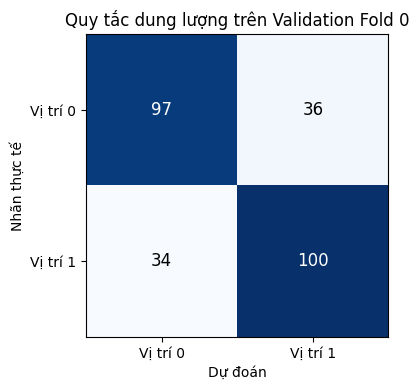

In [7]:
fig, ax = plt.subplots(figsize=(5.0, 4.0))
im = ax.imshow(cm, cmap='Blues')
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, str(val), ha='center', va='center', color='white' if val > cm.max()/2 else 'black', fontsize=12)
ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=['Vị trí 0', 'Vị trí 1'], yticklabels=['Vị trí 0', 'Vị trí 1'],
       xlabel='Dự đoán', ylabel='Nhãn thực tế', title='Quy tắc dung lượng trên Validation Fold 0')
plt.tight_layout()
plt.show()

### Quy tắc sai ở đâu?

Hàng là nhãn thật, cột là nhãn dự đoán. Hai ô trên đường chéo đếm ca đúng; hai ô còn lại cho biết model nhầm về phía nào. Đọc số lỗi cùng Macro-F1, rồi xem các cặp cụ thể bên dưới.

Nếu còn lỗi, dung lượng chưa đủ cho những cặp ấy. Nội dung nền, độ chi tiết và cách nén đều là những cách giải thích có thể xét tiếp. Chỉ nhìn một cặp sai chưa xác định được yếu tố nào gây ra lỗi. Nếu chưa có lỗi trên fold này, hãy giữ kết quả đó và kiểm tra các fold còn lại trước khi kết luận quy tắc dùng tốt ở mọi nơi.

## 5. Minh họa các ca dự đoán đúng và sai

Chúng ta chọn các trường hợp từ tập kiểm định theo thứ tự `pair_id` tăng dần để minh họa. Việc chọn các ca đầu tiên theo thứ tự định danh là một cách minh họa có thể lặp lại và kiểm chứng được, không phải là kết luận rằng các ca này đại diện cho toàn bộ lỗi trong tập dữ liệu.

Đoạn mã dưới đây hiển thị một ca dự đoán đúng và một ca dự đoán sai, kèm kiểm tra danh sách không rỗng để tránh lỗi truy cập.

Ca dự đoán đúng đầu tiên: Cặp 00005, delta_b=-0.1770, Thực tế=1, Đoán=1


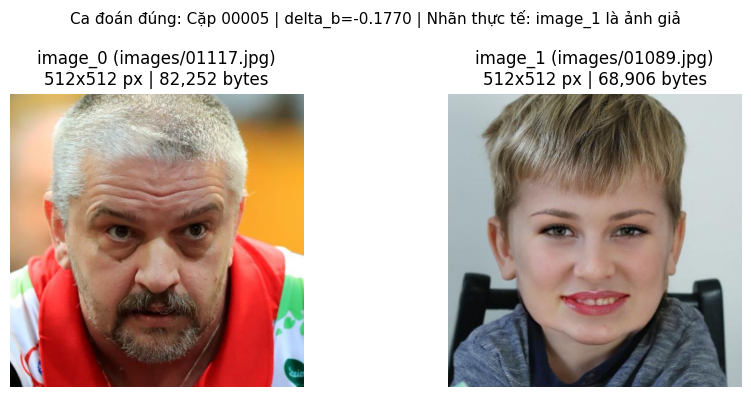

Ca dự đoán sai đầu tiên: Cặp 00016, delta_b=-0.0536, Thực tế=0, Đoán=1


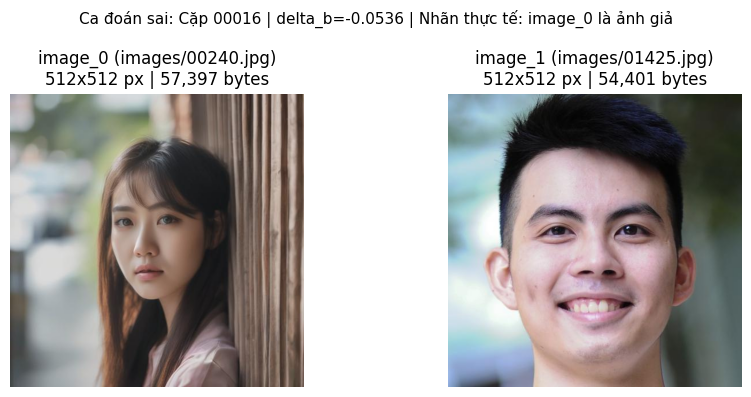

In [8]:
correct_samples = val_df.loc[val_df.is_correct == 1].sort_values('pair_id')
error_samples = val_df.loc[val_df.is_correct == 0].sort_values('pair_id')

if not correct_samples.empty:
    sample_correct = correct_samples.iloc[0]
    print(f"Ca dự đoán đúng đầu tiên: Cặp {sample_correct.pair_id}, delta_b={sample_correct.delta_b:.4f}, Thực tế={sample_correct.fake_position}, Đoán={sample_correct.pred}")
    show_pair_images(sample_correct, data_root, title=f"Ca đoán đúng: Cặp {sample_correct.pair_id} | delta_b={sample_correct.delta_b:.4f}")

if not error_samples.empty:
    sample_error = error_samples.iloc[0]
    print(f"Ca dự đoán sai đầu tiên: Cặp {sample_error.pair_id}, delta_b={sample_error.delta_b:.4f}, Thực tế={sample_error.fake_position}, Đoán={sample_error.pred}")
    show_pair_images(sample_error, data_root, title=f"Ca đoán sai: Cặp {sample_error.pair_id} | delta_b={sample_error.delta_b:.4f}")

## 6. Đo trực tiếp điểm ảnh: màu sắc và độ sáng

Dung lượng trộn ảnh hưởng của nội dung với cách lưu tệp. Ta thử một hướng đo khác ngay trên điểm ảnh: ảnh thật và giả có khác về độ sáng hay độ phân tán màu không?

Bắt đầu bằng ảnh xám để phép đo dễ nhìn. Chuyển mỗi giá trị về [0, 1], với 0 là tối và 1 là sáng:

- Trung bình là tổng giá trị chia cho số điểm ảnh, mô tả độ sáng chung.
- Độ lệch chuẩn mô tả mức phân tán quanh trung bình. Cùng độ sáng chung, ảnh có vùng sáng tối khác nhau có thể có độ lệch chuẩn khác nhau.
- Phân vị 10% và 90% mô tả phía tối và phía sáng của phân bố, ít phụ thuộc vào một điểm cực trị hơn min/max.

In các số này trên cặp vừa xem, sau đó khảo sát phân bố trung bình mức xám trên phần train. Phép chuyển ảnh xám dùng đúng cách tính của thư viện đặc trưng.

In [9]:
bgr0 = cv2.imread(str(p0))
bgr1 = cv2.imread(str(p1))
gray0 = cv2.cvtColor(bgr0, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
gray1 = cv2.cvtColor(bgr1, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

print(f"Cặp mẫu {sample_row.pair_id}:")
print(f"- image_0: mean={gray0.mean():.4f}, std={gray0.std():.4f}, q10={np.quantile(gray0, 0.1):.4f}, q90={np.quantile(gray0, 0.9):.4f}")
print(f"- image_1: mean={gray1.mean():.4f}, std={gray1.std():.4f}, q10={np.quantile(gray1, 0.1):.4f}, q90={np.quantile(gray1, 0.9):.4f}")

real_grays = []
fake_grays = []

for row in tr_fold0.itertuples():
    g0 = float((cv2.cvtColor(cv2.imread(str(data_root / row.image_0)), cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0).mean())
    g1 = float((cv2.cvtColor(cv2.imread(str(data_root / row.image_1)), cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0).mean())
    
    if row.fake_position == 0:
        fake_grays.append(g0)
        real_grays.append(g1)
    else:
        real_grays.append(g0)
        fake_grays.append(g1)

print(f"Trung vị gray_mean ảnh thật: {np.median(real_grays):.4f}")
print(f"Trung vị gray_mean ảnh giả:  {np.median(fake_grays):.4f}")

Cặp mẫu 00001:
- image_0: mean=0.5072, std=0.1924, q10=0.1804, q90=0.7725


- image_1: mean=0.5749, std=0.1870, q10=0.3059, q90=0.8000


Trung vị gray_mean ảnh thật: 0.4431
Trung vị gray_mean ảnh giả:  0.4349


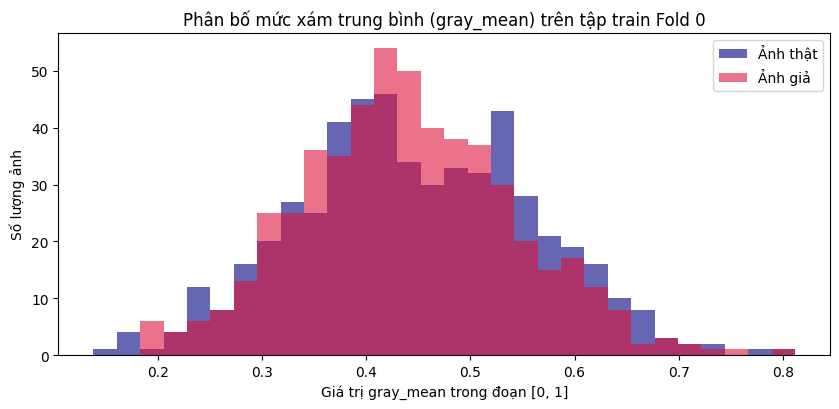

In [10]:
bins_gray = histogram_edges(real_grays, fake_grays)

plt.figure(figsize=(8.5, 4.2))
plt.hist(real_grays, bins=bins_gray, alpha=0.6, color='navy', label='Ảnh thật')
plt.hist(fake_grays, bins=bins_gray, alpha=0.6, color='crimson', label='Ảnh giả')
plt.title("Phân bố mức xám trung bình (gray_mean) trên tập train Fold 0")
plt.xlabel("Giá trị gray_mean trong đoạn [0, 1]")
plt.ylabel("Số lượng ảnh")
plt.legend()
plt.tight_layout()
plt.show()

### Độ sáng có tách được hai nhóm không?

Đọc vị trí các cột trên trục [0, 1]. Nếu hai nhóm gần trùng nhau, phép đo này chưa cho thấy sự phân biệt rõ trên train. Nếu chúng lệch nhau, ta có một tín hiệu ứng viên để thử trên validation. Dù gặp trường hợp nào, không suy nhãn của cả nhóm từ riêng cặp minh họa.

Một số trung bình không cho biết các điểm ảnh sáng tối nằm cạnh nhau thế nào. Câu hỏi tiếp theo là liệu mức thay đổi giữa các điểm ảnh lân cận có cung cấp thêm thông tin không.

## 7. Câu hỏi 3: Kết cấu cục bộ và phần dư tần số cao có làm lộ dấu vết can thiệp?

Liệu các vùng da mịn hoặc chi tiết vi mô có khác biệt giữa hai ảnh trong cặp?
Để quan sát chi tiết tần số cao, chúng ta áp dụng phép lọc mờ Gaussian:
- Phép làm mờ Gaussian (low-pass filter) làm giảm các biến thiên nhanh giữa các điểm ảnh cạnh nhau.
- Phép trừ ảnh gốc cho ảnh mờ tạo ra ảnh phần dư (residual), giữ lại các độ lệch cục bộ so với nền làm mờ như cạnh sắc và nhiễu hạt.
- Tham số $\sigma = 1.2$ là một lựa chọn thang đo ban đầu, không phải giá trị tối ưu.
- `residual_std`: độ lệch chuẩn của phần dư, đo lường mức độ biến động chi tiết cao tần.
- `residual_abs`: giá trị trung bình trị tuyệt đối của phần dư.

Đoạn mã sau hiển thị ảnh gốc, ảnh mờ (giới hạn hiển thị cố định trong đoạn [0, 1]) và ảnh phần dư của cặp mẫu. Khi hiển thị ảnh phần dư, dải màu `vmin` và `vmax` được chia sẻ chung giữa hai ảnh để đảm bảo việc so sánh trực quan là trung thực.

image_0: residual_std=0.0160, residual_abs=0.0084
image_1: residual_std=0.0239, residual_abs=0.0141


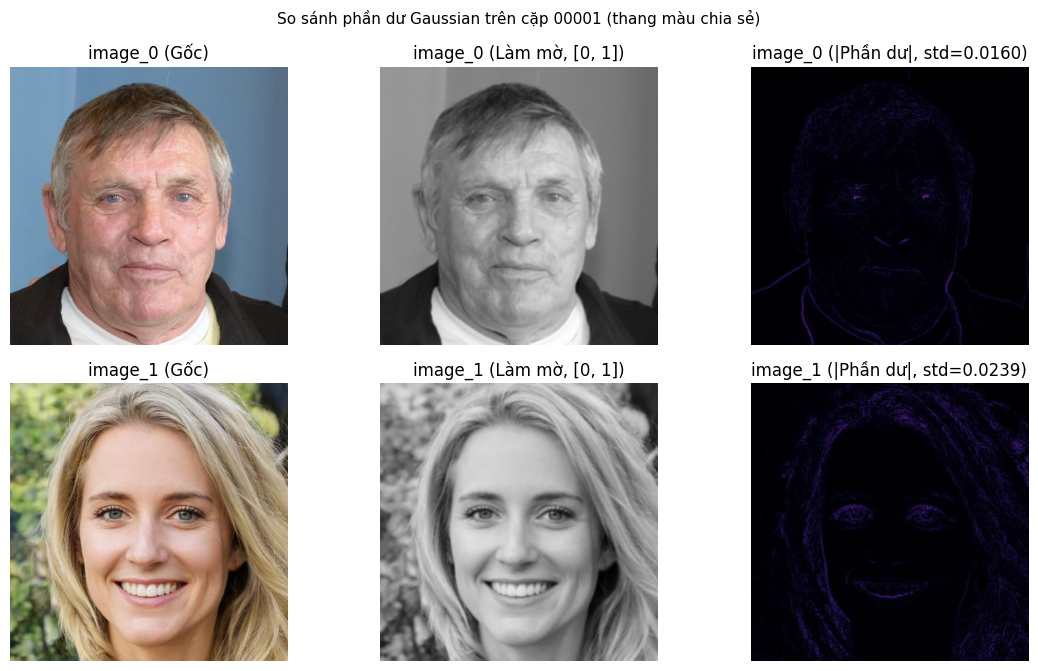

In [11]:
blurred0 = cv2.GaussianBlur(gray0, (0, 0), sigmaX=1.2, sigmaY=1.2)
blurred1 = cv2.GaussianBlur(gray1, (0, 0), sigmaX=1.2, sigmaY=1.2)

residual0 = gray0 - blurred0
residual1 = gray1 - blurred1

res_std0, res_std1 = float(residual0.std()), float(residual1.std())
res_abs0, res_abs1 = float(np.abs(residual0).mean()), float(np.abs(residual1).mean())

print(f"image_0: residual_std={res_std0:.4f}, residual_abs={res_abs0:.4f}")
print(f"image_1: residual_std={res_std1:.4f}, residual_abs={res_abs1:.4f}")

# Chia sẻ khoảng vmin, vmax giữa hai ảnh để so sánh trung thực
abs_res0 = np.abs(residual0)
abs_res1 = np.abs(residual1)
v_min = float(min(abs_res0.min(), abs_res1.min()))
v_max = float(max(abs_res0.max(), abs_res1.max()))

fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.8))
axes[0, 0].imshow(cv2.cvtColor(bgr0, cv2.COLOR_BGR2RGB)); axes[0, 0].set_title("image_0 (Gốc)"); axes[0, 0].axis('off')
axes[0, 1].imshow(blurred0, cmap='gray', vmin=0.0, vmax=1.0); axes[0, 1].set_title("image_0 (Làm mờ, [0, 1])"); axes[0, 1].axis('off')
axes[0, 2].imshow(abs_res0, cmap='magma', vmin=v_min, vmax=v_max); axes[0, 2].set_title(f"image_0 (|Phần dư|, std={res_std0:.4f})"); axes[0, 2].axis('off')

axes[1, 0].imshow(cv2.cvtColor(bgr1, cv2.COLOR_BGR2RGB)); axes[1, 0].set_title("image_1 (Gốc)"); axes[1, 0].axis('off')
axes[1, 1].imshow(blurred1, cmap='gray', vmin=0.0, vmax=1.0); axes[1, 1].set_title("image_1 (Làm mờ, [0, 1])"); axes[1, 1].axis('off')
axes[1, 2].imshow(abs_res1, cmap='magma', vmin=v_min, vmax=v_max); axes[1, 2].set_title(f"image_1 (|Phần dư|, std={res_std1:.4f})"); axes[1, 2].axis('off')

fig.suptitle(f"So sánh phần dư Gaussian trên cặp {sample_row.pair_id} (thang màu chia sẻ)", fontsize=11)
plt.tight_layout()
plt.show()

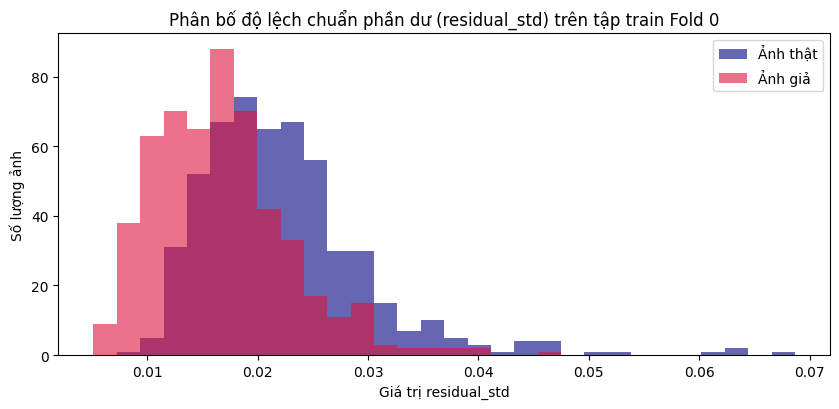

Trung vị residual_std ảnh thật: 0.0210
Trung vị residual_std ảnh giả:  0.0162


In [12]:
real_residuals = []
fake_residuals = []

for row in tr_fold0.itertuples():
    g0 = cv2.cvtColor(cv2.imread(str(data_root / row.image_0)), cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    g1 = cv2.cvtColor(cv2.imread(str(data_root / row.image_1)), cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    
    r0 = g0 - cv2.GaussianBlur(g0, (0, 0), sigmaX=1.2, sigmaY=1.2)
    r1 = g1 - cv2.GaussianBlur(g1, (0, 0), sigmaX=1.2, sigmaY=1.2)
    
    s0, s1 = float(r0.std()), float(r1.std())
    if row.fake_position == 0:
        fake_residuals.append(s0)
        real_residuals.append(s1)
    else:
        real_residuals.append(s0)
        fake_residuals.append(s1)

bins_res = histogram_edges(real_residuals, fake_residuals)

plt.figure(figsize=(8.5, 4.2))
plt.hist(real_residuals, bins=bins_res, alpha=0.6, color='navy', label='Ảnh thật')
plt.hist(fake_residuals, bins=bins_res, alpha=0.6, color='crimson', label='Ảnh giả')
plt.title("Phân bố độ lệch chuẩn phần dư (residual_std) trên tập train Fold 0")
plt.xlabel("Giá trị residual_std")
plt.ylabel("Số lượng ảnh")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Trung vị residual_std ảnh thật: {np.median(real_residuals):.4f}")
print(f"Trung vị residual_std ảnh giả:  {np.median(fake_residuals):.4f}")

### Phần dư bổ sung điều gì so với độ sáng?

Trục ngang là độ lệch chuẩn của phần dư. Giá trị lớn hơn nghĩa là các độ lệch so với ảnh mờ phân tán hơn ở thang lọc đã chọn; biên tóc, nền và nhiễu cũng có thể góp vào số đo này.

Đối chiếu hai phân bố: có lệch nhau không, phần chồng lấn rộng hay hẹp? Nếu khác biệt rõ hơn biểu đồ độ sáng, ta có lý do thử phép đo trong model. Nếu gần trùng nhau, vẫn cần xem nó có bổ sung khi kết hợp với phép đo khác hay không. Một histogram riêng chưa trả lời được câu hỏi kết hợp đó.

## 8. Vị trí trong ảnh có quan trọng không?

Các phép đo vừa rồi tóm tắt toàn ảnh. Với ảnh chân dung, ta có thể hỏi liệu vùng giữa và phần xung quanh có khác nhau về độ sáng hay mức biến thiên không. Hình chữ nhật dưới đây giúp kiểm tra vùng đo thực sự bao gồm những gì.

Ta chọn 60% mỗi chiều ở giữa, từ 20% đến 80% chiều cao và chiều rộng. Tỷ lệ này tương đương khoảng 36% diện tích trước khi làm tròn tọa độ. Đây là cách chia vùng khởi đầu, chưa được chứng minh tốt hơn 50% hay 70%; nó không định vị khuôn mặt bằng landmarks.

Ví dụ dùng hiệu `center_mean - border_mean`: số dương nghĩa là vùng giữa sáng hơn phần ngoài. Bài LR sẽ giữ riêng mean và std của cả hai vùng để model học cách kết hợp.

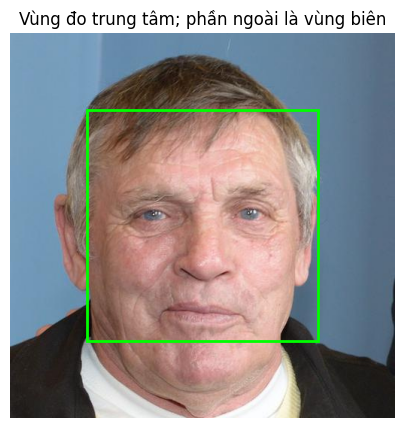

image_0: center_mean=0.5934, border_mean=0.4589, hiệu=0.1346
image_1: center_mean=0.6097, border_mean=0.5554, hiệu=0.0543


In [13]:
from kmd.extractor import extract_center_border_stats
from matplotlib.patches import Rectangle

def get_center_border_stats(gray_img):
    center_mean, _, border_mean, _ = extract_center_border_stats(gray_img)
    return center_mean, border_mean

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(cv2.cvtColor(bgr0, cv2.COLOR_BGR2RGB))
h, w = gray0.shape
left, right = int(.2 * w), int(.8 * w)
top, bottom = int(.2 * h), int(.8 * h)
ax.add_patch(Rectangle((left, top), right-left, bottom-top,
                       fill=False, edgecolor='lime', linewidth=2))
ax.set_title('Vùng đo trung tâm; phần ngoài là vùng biên')
ax.axis('off')
plt.show()

c_m0, b_m0 = get_center_border_stats(gray0)
c_m1, b_m1 = get_center_border_stats(gray1)
print(f"image_0: center_mean={c_m0:.4f}, border_mean={b_m0:.4f}, hiệu={c_m0 - b_m0:.4f}")
print(f"image_1: center_mean={c_m1:.4f}, border_mean={b_m1:.4f}, hiệu={c_m1 - b_m1:.4f}")

Bây giờ tính lại vùng giữa và phần ngoài theo kích thước của từng ảnh train. Ta vẽ hiệu hai mức sáng để xem xu hướng của cả hai nhóm, thay vì suy từ cặp mẫu.

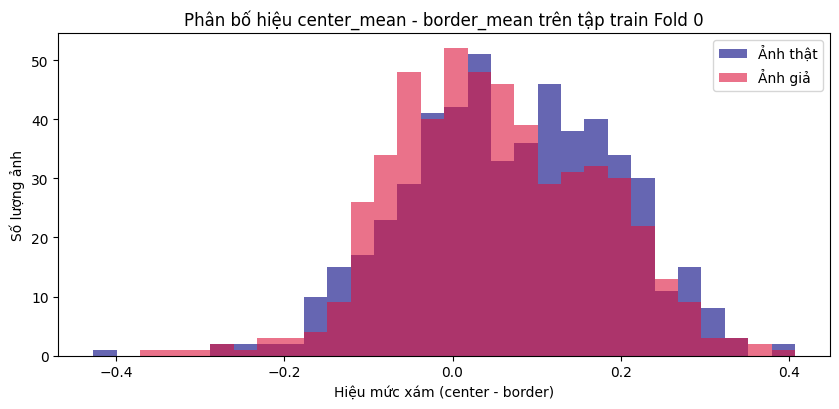

Trung vị hiệu (center - border) ảnh thật: 0.0713
Trung vị hiệu (center - border) ảnh giả:  0.0439


In [14]:
real_diffs = []
fake_diffs = []

for row in tr_fold0.itertuples():
    g0 = cv2.cvtColor(cv2.imread(str(data_root / row.image_0)), cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    g1 = cv2.cvtColor(cv2.imread(str(data_root / row.image_1)), cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    
    c0, b0_val = get_center_border_stats(g0)
    c1, b1_val = get_center_border_stats(g1)
    d0 = c0 - b0_val
    d1 = c1 - b1_val
    
    if row.fake_position == 0:
        fake_diffs.append(d0)
        real_diffs.append(d1)
    else:
        real_diffs.append(d0)
        fake_diffs.append(d1)

bins_diff = histogram_edges(real_diffs, fake_diffs)

plt.figure(figsize=(8.5, 4.2))
plt.hist(real_diffs, bins=bins_diff, alpha=0.6, color='navy', label='Ảnh thật')
plt.hist(fake_diffs, bins=bins_diff, alpha=0.6, color='crimson', label='Ảnh giả')
plt.title("Phân bố hiệu center_mean - border_mean trên tập train Fold 0")
plt.xlabel("Hiệu mức xám (center - border)")
plt.ylabel("Số lượng ảnh")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Trung vị hiệu (center - border) ảnh thật: {np.median(real_diffs):.4f}")
print(f"Trung vị hiệu (center - border) ảnh giả:  {np.median(fake_diffs):.4f}")

### Từ các phép đo sang một giả thuyết có thể kiểm tra

Ở biểu đồ cuối, giá trị quanh 0 nghĩa là độ sáng trung bình giữa hai vùng gần nhau. Hãy xem hai nhóm khác nhau ở phía nào và có chồng lấn không. Khác biệt về vùng đo chưa đủ để khẳng định ảnh đã bị chỉnh sửa tại vùng đó.

Trước khi sang bài tiếp, ghi lại: quy tắc dung lượng đạt bao nhiêu lỗi trên validation; những phép đo nào có phân bố khác nhau trên train; điều gì còn chưa rõ từ các hình vừa xem. Nếu chưa thấy khác biệt ở một phép đo, cũng ghi lại điều đó.

Ta đã có bốn hướng đo: thuộc tính tệp, màu và độ sáng, thay đổi cục bộ, phân bố giữa các vùng. Chúng có thể liên quan với nhau; chưa có phép thử nào ở đây chứng minh chúng độc lập. Câu hỏi tiếp theo là: **kết hợp chúng có giúp hơn quy tắc đơn lẻ không, và nhóm nào còn bổ sung khi đã có các nhóm khác?**

[Bài 02](02_features_and_lr.ipynb) dùng Logistic Regression để thử hai câu hỏi đó trên cùng cách chia dữ liệu.